# MIMIC-III Demo — Clasificación (fallecimiento hospitalario)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

- **Origen**: **MIMIC-III** (Medical Information Mart for Intensive Care), datos de la **Beth Israel Deaconess Medical Center** (Boston); versión **demo** reducida.
- **Contexto real**: admisiones a UCI/hospital con diagnósticos, tiempos y desenlaces.
- **Tarea ML**: **clasificación binaria**.
- **Variable objetivo `y`**: `hospital_expire_flag` (**0** = alta viva, **1** = fallecimiento durante la estancia hospitalaria según el registro).

Unimos **ADMISSIONS** con **PATIENTS** por `subject_id` para añadir sexo y edad aproximada.

In [1]:
import warnings  # Silenciar avisos
warnings.filterwarnings("ignore")  # Ignorar warnings
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # DataFrames
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Graficos stats
from IPython.display import display  # Tablas Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Preprocesamiento
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto primerparcial_ia

mimic_root = list(ROOT_NB.glob("2. MIMIC*"))[0]  # Carpeta MIMIC con nombre unicode
mimic_data = mimic_root / "mimic-iii-clinical-database-demo-1.4"  # Subcarpeta datos
adm = pd.read_csv(mimic_data / "ADMISSIONS.csv")  # Tabla admisiones
pat = pd.read_csv(mimic_data / "PATIENTS.csv")  # Tabla pacientes
df = adm.merge(pat, on="subject_id", how="left", suffixes=("", "_pat"))  # Unir por paciente
print("Forma tras merge:", df.shape)  # Dimension
display(df.head(10))  # Muestra
print("shape:", df.shape)  # Repetir shape
print("dtypes:\n", df.dtypes)  # Tipos
display(df.describe(include="all").T.head(25))  # Describe


Forma tras merge: (129, 26)


,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,...,diagnosis,hospital_expire_flag,has_chartevents_data,row_id_pat,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
0,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,...,SEPSIS,0,1,9467,F,2094-03-05 00:00:00,2165-08-12 00:00:00,2165-08-12 00:00:00,2165-08-12 00:00:00,1
1,12263,10011,105331,2126-08-14 22:32:00,2126-08-28 18:59:00,2126-08-28 18:59:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,...,HEPATITIS B,1,1,9472,F,2090-06-05 00:00:00,2126-08-28 00:00:00,2126-08-28 00:00:00,NaN,1
2,12265,10013,165520,2125-10-04 23:36:00,2125-10-07 15:13:00,2125-10-07 15:13:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,...,SEPSIS,1,1,9474,F,2038-09-03 00:00:00,2125-10-07 00:00:00,2125-10-07 00:00:00,2125-10-07 00:00:00,1
3,12269,10017,199207,2149-05-26 17:19:00,2149-06-03 18:42:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,...,HUMERAL FRACTURE,0,1,9478,F,2075-09-21 00:00:00,2152-09-12 00:00:00,NaN,2152-09-12 00:00:00,1
4,12270,10019,177759,2163-05-14 20:43:00,2163-05-15 12:00:00,2163-05-15 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,...,ALCOHOLIC HEPATITIS,1,1,9479,M,2114-06-20 00:00:00,2163-05-15 00:00:00,2163-05-15 00:00:00,2163-05-15 00:00:00,1
5,12277,10026,103770,2195-05-17 07:39:00,2195-05-24 11:45:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,REHAB/DISTINCT PART HOSP,Medicare,...,STROKE/TIA,0,1,9486,F,1895-05-17 00:00:00,2195-11-24 00:00:00,NaN,2195-11-24 00:00:00,1
6,12278,10027,199395,2190-07-13 07:15:00,2190-07-25 14:00:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,SNF,Medicare,...,MITRAL REGURGITATION;CORONARY ARTERY DISEASE\...,0,1,9487,F,2108-01-15 00:00:00,2190-09-14 00:00:00,NaN,2190-09-14 00:00:00,1
7,12280,10029,132349,2139-09-22 10:58:00,2139-10-02 14:29:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,...,SYNCOPE;TELEMETRY,0,1,9489,M,2061-04-10 00:00:00,2140-09-21 00:00:00,NaN,2140-09-21 00:00:00,1
8,12282,10032,140372,2138-04-02 19:52:00,2138-04-15 14:35:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,REHAB/DISTINCT PART HOSP,Medicare,...,RIGHT HUMEROUS FRACTURE,0,1,9491,M,2050-03-29 00:00:00,2138-05-21 00:00:00,2138-05-21 00:00:00,2138-05-21 00:00:00,1
9,12283,10033,157235,2132-12-05 02:46:00,2132-12-08 15:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,...,RENAL FAILIURE-SYNCOPE-HYPERKALEMIA,0,1,9492,F,2051-04-21 00:00:00,2133-09-09 00:00:00,NaN,2133-09-09 00:00:00,1


shape: (129, 26)
dtypes:
 row_id                  int64
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admission_location        str
discharge_location        str
insurance                 str
language                  str
religion                  str
marital_status            str
ethnicity                 str
edregtime                 str
edouttime                 str
diagnosis                 str
hospital_expire_flag    int64
has_chartevents_data    int64
row_id_pat              int64
gender                    str
dob                       str
dod                       str
dod_hosp                  str
dod_ssn                   str
expire_flag             int64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
row_id,129.0,NaN,NaN,NaN,28036.44186,14036.548988,12258.0,12339.0,39869.0,40463.0,41092.0
subject_id,129.0,NaN,NaN,NaN,28010.410853,16048.502883,10006.0,10088.0,40310.0,42135.0,44228.0
hadm_id,129.0,NaN,NaN,NaN,152343.44186,27858.788248,100375.0,128293.0,157235.0,174739.0,199395.0
admittime,129,129,2164-10-23 21:09:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dischtime,129,129,2164-11-01 17:15:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deathtime,40,40,2126-08-28 18:59:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type,129,3,EMERGENCY,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_location,129,5,EMERGENCY ROOM ADMIT,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_location,129,10,DEAD/EXPIRED,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,129,4,Medicare,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## SECCIÓN 1 — SANEAMIENTO

- **Mediana** en numéricos: robustez a outliers (p. ej. tiempos).
- **Moda** en categóricas: valor más frecuente.
- **Eliminar duplicados** de filas.
- **Eliminar columnas** con >40% nulos o identificadores (`row_id`, `hadm_id`, `subject_id`) que no deben usarse como predictores directos (riesgo de fuga de información o sobreajuste espurio).
- **Fechas**: convertir a numérico (timestamp o año) para modelos.

In [2]:
df1 = df.copy()  # Copia
print("Nulos ANTES:\n", df1.isnull().sum().sort_values(ascending=False).head(20))  # Nulos
df1 = df1.drop_duplicates()  # Quitar duplicados
null_ratio = df1.isnull().mean()  # Ratio nulos
df1 = df1.drop(columns=null_ratio[null_ratio > 0.40].index.tolist(), errors="ignore")  # >40% nulos
drop_ids = [c for c in ("row_id", "hadm_id", "subject_id") if c in df1.columns]  # IDs
print("Columnas ID eliminadas (no predictores causales directos):", drop_ids)  # Log
df1 = df1.drop(columns=drop_ids, errors="ignore")  # Borrar IDs
# Fechas a epoch segundos (simplificado)
for col in list(df1.columns):
    if "time" in col.lower() or col in ("dob", "dod", "dod_hosp", "dod_ssn", "admittime", "dischtime", "deathtime", "edregtime", "edouttime"):
        if col in df1.columns:
            df1[col] = pd.to_datetime(df1[col], errors="coerce")  # Parseo fecha
            df1[col] = df1[col].astype("int64", errors="ignore") // 10**9  # Segundos epoch aprox
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for col in num_cols:
    df1[col] = df1[col].fillna(df1[col].median())  # Mediana
for col in cat_cols:
    if df1[col].isnull().any():
        m = df1[col].mode()
        df1[col] = df1[col].fillna(m.iloc[0] if len(m) else "")  # Moda
print("Nulos DESPUES (suma total):", df1.isnull().sum().sum())  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES:
 deathtime               89
language                48
dod_hosp                48
edouttime               37
edregtime               37
dod_ssn                 25
marital_status          16
religion                 1
subject_id               0
row_id                   0
insurance                0
discharge_location       0
admission_location       0
admission_type           0
dischtime                0
admittime                0
hadm_id                  0
ethnicity                0
hospital_expire_flag     0
diagnosis                0
dtype: int64
Columnas ID eliminadas (no predictores causales directos): ['row_id', 'hadm_id', 'subject_id']
Nulos DESPUES (suma total): 0


## SECCIÓN 2 — X e y

- **y** = `hospital_expire_flag`
- **X** = resto de columnas (sin la objetivo).

Gráfico de barras de clases; correlación con la etiqueta codificada numéricamente para features numéricas.

X.shape (129, 21) y.shape (129,)
hospital_expire_flag
0    89
1    40
Name: count, dtype: int64


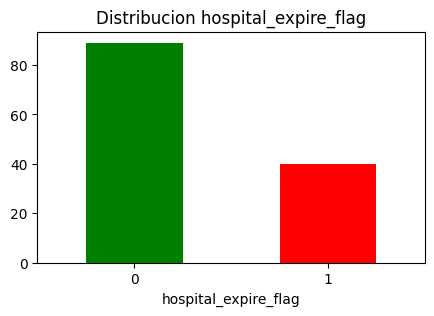

Proporciones: hospital_expire_flag
0    0.689922
1    0.310078
Name: proportion, dtype: float64
Top 5 correlaciones con y: dod_hosp      0.516075
dod_ssn       0.307345
dod           0.160935
row_id_pat    0.145411
dischtime     0.141479
dtype: float64


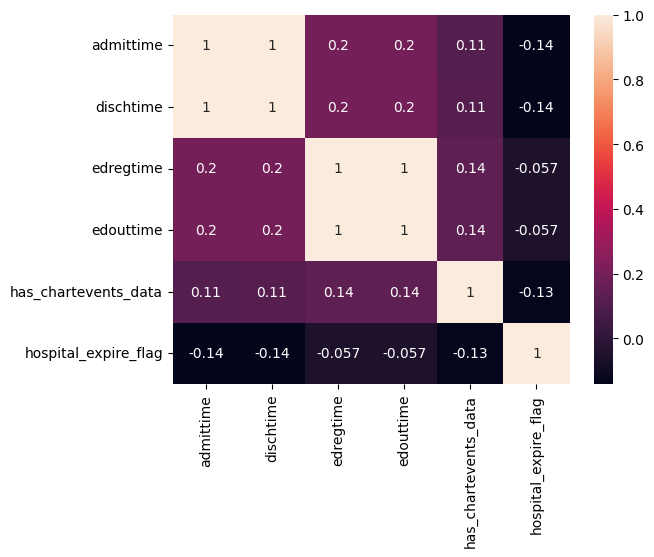

In [3]:
y = df_clean["hospital_expire_flag"].astype(int)  # Objetivo binario
X = df_clean.drop(columns=["hospital_expire_flag"])  # Features
print("X.shape", X.shape, "y.shape", y.shape)  # Shapes
print(y.value_counts())  # Distribucion clases
plt.figure(figsize=(5,3))  # Figura
y.value_counts().plot(kind="bar", color=["green","red"])  # Barras
plt.title("Distribucion hospital_expire_flag")  # Titulo
plt.xticks(rotation=0)  # Etiquetas
plt.show()  # Mostrar
imb = y.value_counts(normalize=True)  # Proporciones
print("Proporciones:", imb)  # Imbalance
if imb.min() < 0.2:
    print("Clases desbalanceadas: una clase es rara; implica metricas como F1 y estrategias de balanceo.")  # Nota
# Correlacion con objetivo (numerico)
num_x = X.select_dtypes(include=[np.number]).columns  # Num features
if len(num_x) > 0:
    corr = X[num_x].corrwith(y).abs().sort_values(ascending=False)  # Corr
    print("Top 5 correlaciones con y:", corr.head(5))  # Top 5
    sns.heatmap(pd.concat([X[num_x[:min(5,len(num_x))]], y], axis=1).corr(), annot=True)  # Heatmap pequeno
    plt.show()


## SECCIÓN 3 — ENCODING

- **Nominales** (p. ej. tipo de admisión, seguro): **one-hot**.
- **Ordinales** si las hubiera con orden claro: **LabelEncoder**; aquí muchas categóricas son nominales.

In [4]:
X_enc = X.copy()  # Copia
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # No numericas
print("Categoricas antes:", non_num)  # Lista
X_enc = pd.get_dummies(X_enc, columns=non_num, drop_first=False)  # One-hot todo (nominal predominante)
print("Num columnas despues encoding:", X_enc.shape[1])  # Conteo
display(X_enc.head(5))  # Muestra


Categoricas antes: ['admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'religion', 'marital_status', 'ethnicity', 'diagnosis', 'gender']
Num columnas despues encoding: 160


,admittime,dischtime,edregtime,edouttime,has_chartevents_data,row_id_pat,dob,dod,dod_hosp,dod_ssn,...,diagnosis_UNSTABLE ANGINA,diagnosis_UPPER GI BLEED,diagnosis_URINARY TRACT INFECTION;PYELONEPHRITIS,diagnosis_UROSEPSIS,diagnosis_UTI/PYELONEPHRITIS,diagnosis_VARICEAL BLEED,diagnosis_VF ARREST,diagnosis_VOLVULUS,gender_F,gender_M
0,6147695,6148458,6147679,6147702,1,9467,3918585,6172934,6172934,6172934,...,False,False,False,False,False,False,False,False,True,False
1,4942420,4943617,-9223372037,-9223372037,1,9472,3800304,4943548,4943548,-9223372037,...,False,False,False,False,False,False,False,False,True,False
2,4915294,4915523,-9223372037,-9223372037,1,9474,2167084,4915468,4915468,4915468,...,False,False,False,False,False,False,False,False,True,False
3,5661335,5662032,5661317,5661344,1,9478,3336249,5765385,-9223372037,5765385,...,False,False,False,False,False,False,False,False,True,False
4,6102074,6102129,-9223372037,-9223372037,1,9479,4558896,6102086,6102086,6102086,...,False,False,False,False,False,False,False,False,False,True


## SECCIÓN 4 — NORMALIZACIÓN (StandardScaler)

Comparación 5 filas antes/después en primeras columnas.

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste y transformacion
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DataFrame
antes = X_enc.iloc[:5, :6] if X_enc.shape[1] >= 6 else X_enc.iloc[:5]  # Antes (subcolumnas)
despues = X_scaled_df.iloc[:5, :6] if X_scaled_df.shape[1] >= 6 else X_scaled_df.iloc[:5]  # Despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES                                                                    \
  admittime dischtime   edregtime   edouttime has_chartevents_data row_id_pat   
0   6147695   6148458     6147679     6147702                    1       9467   
1   4942420   4943617 -9223372037 -9223372037                    1       9472   
2   4915294   4915523 -9223372037 -9223372037                    1       9474   
3   5661335   5662032     5661317     5661344                    1       9478   
4   6102074   6102129 -9223372037 -9223372037                    1       9479   

    DESPUES                                                                
  admittime dischtime edregtime edouttime has_chartevents_data row_id_pat  
0  0.345299  0.345264  0.634222  0.634222             0.088388  -1.129584  
1 -0.905548 -0.905168 -1.576860 -1.576860             0.088388  -1.129123  
2 -0.933700 -0.934325 -1.576860 -1.576860             0.088388  -1.128939  
3 -0.159450 -0.159568  0.634106  0.634106             0.088388  -1.128570  
4  0.297953  0.297182 -1.576860 -1.576860             0.088388  -1.128478

## SECCIÓN 5 — TRAIN/TEST (80/20, random_state=42)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)  # Estratificar clases
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Shapes


(103, 160) (26, 160) (103,) (26,)


## SECCIÓN 6 — Baseline: LogisticRegression(max_iter=1000)

In [7]:
clf = LogisticRegression(max_iter=1000)  # Modelo lineal clasico
clf.fit(X_train, y_train)  # Entrenar
acc = accuracy_score(y_test, clf.predict(X_test))  # Precision en test
print("Accuracy test:", round(acc, 4))  # Metrica
print("Accuracy = proporcion de aciertos; 1.0 es perfecto.")  # Significado
r2 = acc  # Guardar score para README


Accuracy test: 1.0
Accuracy = proporcion de aciertos; 1.0 es perfecto.


## SECCIÓN 7 — GUARDADO CSV

In [8]:
out_dir = list(ROOT_NB.glob("2. MIMIC*"))[0]  # Carpeta dataset
df_final_ml = pd.concat([X_scaled_df, y.rename("hospital_expire_flag")], axis=1)  # Final
df_final_ml.to_csv(out_dir / "mimic_iii_clean.csv", index=False)  # Limpio
print("Guardado mimic_iii_clean.csv")  # Ok
X_train.to_csv(out_dir / "X_train.csv", index=False)  # Train X
X_test.to_csv(out_dir / "X_test.csv", index=False)  # Test X
y_train.to_csv(out_dir / "y_train.csv", index=True, header=True)  # y train
y_test.to_csv(out_dir / "y_test.csv", index=True, header=True)  # y test
print("Splits guardados")  # Ok


Guardado mimic_iii_clean.csv
Splits guardados


## SECCIÓN 8 — RESUMEN Y ASSERTS

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0  # Sin nulos
assert np.all(np.isfinite(X_scaled_df.values))  # Finitos
print("+----------- RESUMEN -----------+")  # Caja
print("| MIMIC-III demo | Clasificacion | hospital_expire_flag |")  # Linea
print("| Test accuracy:", round(acc, 4), "|")  # Score
print("+--------------------------------+")  # Fin


,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,...,diagnosis,hospital_expire_flag,has_chartevents_data,row_id_pat,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
0,6147695,6148458,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,...,SEPSIS,0,1,9467,F,3918585,6172934,6172934,6172934,1
1,4942420,4943617,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,ENGL,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,...,HEPATITIS B,1,1,9472,F,3800304,4943548,4943548,-9223372037,1
2,4915294,4915523,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,ENGL,CATHOLIC,MARRIED,UNKNOWN/NOT SPECIFIED,...,SEPSIS,1,1,9474,F,2167084,4915468,4915468,4915468,1
3,5661335,5662032,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,ENGL,CATHOLIC,DIVORCED,WHITE,...,HUMERAL FRACTURE,0,1,9478,F,3336249,5765385,-9223372037,5765385,1
4,6102074,6102129,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,ENGL,CATHOLIC,DIVORCED,WHITE,...,ALCOHOLIC HEPATITIS,1,1,9479,M,4558896,6102086,6102086,6102086,1
5,7112129,7112749,EMERGENCY,EMERGENCY ROOM ADMIT,REHAB/DISTINCT PART HOSP,Medicare,ENGL,OTHER,MARRIED,WHITE,...,STROKE/TIA,0,1,9486,F,-2355005,7128604,-9223372037,7128604,1
6,6959286,6960348,ELECTIVE,PHYS REFERRAL/NORMAL DELI,SNF,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,...,MITRAL REGURGITATION;CORONARY ARTERY DISEASE\...,0,1,9487,F,4356028,6964704,-9223372037,6964704,1
7,5355975,5356852,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,ENGL,PROTESTANT QUAKER,DIVORCED,WHITE,...,SYNCOPE;TELEMETRY,0,1,9489,M,2880316,5387472,-9223372037,5387472,1
8,5309524,5310628,EMERGENCY,EMERGENCY ROOM ADMIT,REHAB/DISTINCT PART HOSP,Medicare,ENGL,CATHOLIC,WIDOWED,WHITE,...,RIGHT HUMEROUS FRACTURE,0,1,9491,M,2532124,5313686,5313686,5313686,1
9,5141501,5141805,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,POLI,CATHOLIC,MARRIED,WHITE,...,RENAL FAILIURE-SYNCOPE-HYPERKALEMIA,0,1,9492,F,2565648,5165510,-9223372037,5165510,1


+----------- RESUMEN -----------+
| MIMIC-III demo | Clasificacion | hospital_expire_flag |
| Test accuracy: 1.0 |
+--------------------------------+
